# Model Robustness Testing

Stress-testing ARIMA(1,1,2) to understand how it behaves under adverse conditions. A production model must handle noisy inputs, missing data and edge cases without breaking.

**Tests:**
1. **Gaussian Noise Injection** to measure how RMSE degrades as input noise increases
2. **Monte Carlo Simulation** to get a distribution of RMSE across 1,000 perturbed scenarios
3. **Missing Data Tolerance** to see what happens at 5%, 10% and 20% missing values
4. **Outlier Sensitivity** to check how extreme spikes propagate into future predictions
5. **Seasonal Robustness** to verify performance is consistent across winter and summer

**Data:** 778 unseen days from `actual_vs_predicted.csv` and training data from `clean_daily_my1`

In [1]:
import sys
import os
import pickle
import sqlite3
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
from joblib import Parallel, delayed
import warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, os.path.join(os.getcwd(), ".."))
from config import DB_PATH

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120
np.random.seed(42)

conn = sqlite3.connect(DB_PATH)
clean = pd.read_sql("SELECT * FROM clean_daily_my1", conn, parse_dates=["timestamp"], index_col="timestamp")
conn.close()

unseen = pd.read_csv("logs/actual_vs_predicted.csv", parse_dates=["date"], index_col="date")
baseline_rmse = np.sqrt(mean_squared_error(unseen["actual"], unseen["predicted"]))

train_no2 = clean["no2"].values
no2_std = clean["no2"].std()
n_cores = os.cpu_count()

print(f"Training: {len(train_no2)} days")
print(f"Unseen:   {len(unseen)} days")
print(f"NO2 std:  {no2_std:.2f}")
print(f"Baseline RMSE (no perturbation): {baseline_rmse:.2f}")
print(f"CPU cores available: {n_cores}")

Training: 1752 days
Unseen:   778 days
NO2 std:  18.23
Baseline RMSE (no perturbation): 9.98
CPU cores available: 8


## 1. Gaussian Noise Injection

Adding Gaussian noise to the input history at increasing levels from 1% to 50% of NO2's standard deviation. For each noise level we re-run 50 days of rolling prediction with 10 repeats and measure how RMSE degrades. This produces a sensitivity curve showing the model's tolerance to input corruption.

Running 80 noise trials across 8 cores...
  Noise   0.0% (sigma=0.00): RMSE = 9.77 +/- 0.00
  Noise   1.0% (sigma=0.18): RMSE = 9.77 +/- 0.00
  Noise   2.0% (sigma=0.36): RMSE = 9.77 +/- 0.00
  Noise   5.0% (sigma=0.91): RMSE = 9.78 +/- 0.01
  Noise  10.0% (sigma=1.82): RMSE = 9.79 +/- 0.01
  Noise  20.0% (sigma=3.65): RMSE = 9.83 +/- 0.02
  Noise  30.0% (sigma=5.47): RMSE = 9.89 +/- 0.06
  Noise  50.0% (sigma=9.12): RMSE = 10.15 +/- 0.07

Completed in 1m 27s


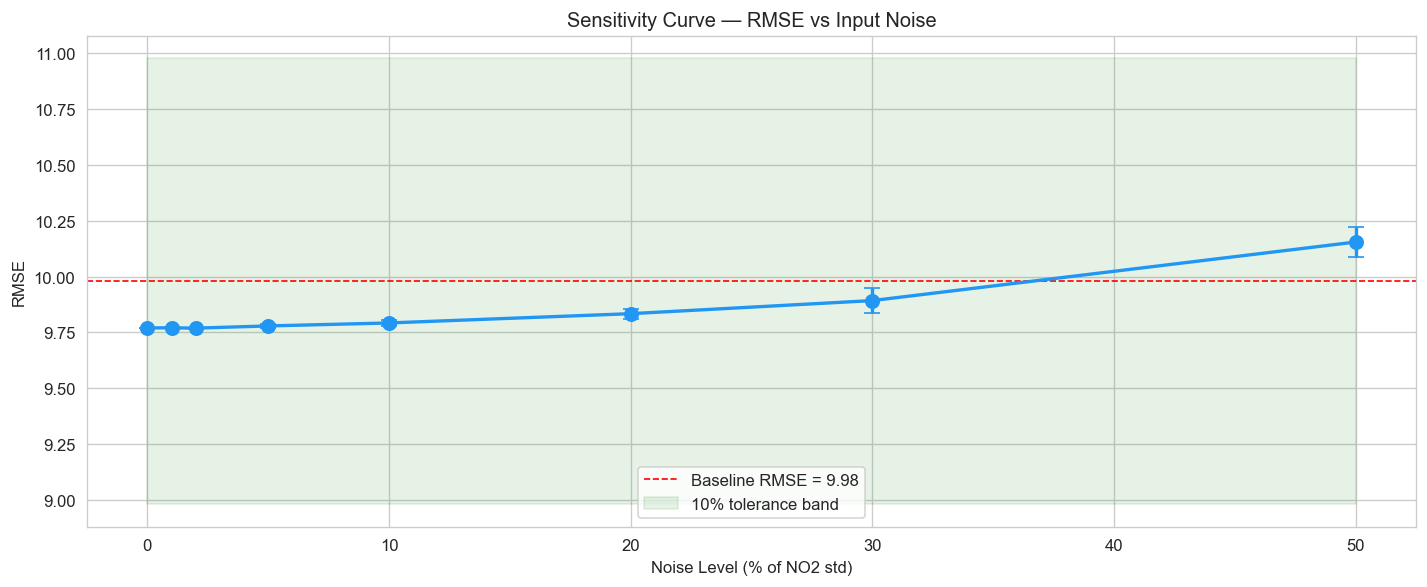


RMSE increase from 0% to 50% noise: 3.9%


In [2]:
def rolling_predict_n(history, actuals, n_days, order=(1,1,2)):
    """Run n_days of rolling ARIMA prediction."""
    h = list(history)
    preds = []
    for i in range(n_days):
        try:
            model = ARIMA(h, order=order)
            fitted = model.fit()
            pred = fitted.forecast(steps=1)[0]
        except Exception:
            pred = np.mean(h[-30:])
        preds.append(pred)
        h.append(actuals[i])
    return preds

noise_levels = [0, 0.01, 0.02, 0.05, 0.10, 0.20, 0.30, 0.50]
n_eval = 50
n_repeats = 10
actuals_subset = unseen["actual"].values[:n_eval]

def run_noise_trial(noise_sigma, seed):
    rng = np.random.RandomState(seed)
    noisy_history = train_no2 + rng.normal(0, noise_sigma, len(train_no2)) if noise_sigma > 0 else train_no2.copy()
    preds = rolling_predict_n(noisy_history, actuals_subset, n_eval)
    return np.sqrt(np.mean((actuals_subset - np.array(preds))**2))

tasks = [(noise_frac * no2_std, int(noise_frac * 10000) + rep)
         for noise_frac in noise_levels for rep in range(n_repeats)]

print(f"Running {len(tasks)} noise trials across {n_cores} cores...")
start_time = time.time()
all_rmses = Parallel(n_jobs=n_cores)(delayed(run_noise_trial)(s, sd) for s, sd in tasks)
elapsed = time.time() - start_time

results = []
idx = 0
for noise_frac in noise_levels:
    rmses = all_rmses[idx:idx + n_repeats]
    idx += n_repeats
    results.append({
        "noise_pct": noise_frac * 100, "noise_sigma": noise_frac * no2_std,
        "rmse_mean": np.mean(rmses), "rmse_std": np.std(rmses),
    })
    print(f"  Noise {noise_frac*100:5.1f}% (sigma={noise_frac * no2_std:.2f}): RMSE = {np.mean(rmses):.2f} +/- {np.std(rmses):.2f}")

results_df = pd.DataFrame(results)
print(f"\nCompleted in {int(elapsed//60)}m {int(elapsed%60)}s")

fig, ax = plt.subplots(figsize=(12, 5))
ax.errorbar(results_df["noise_pct"], results_df["rmse_mean"], yerr=results_df["rmse_std"],
            fmt="o-", color="#2196F3", capsize=5, linewidth=2, markersize=8)
ax.axhline(baseline_rmse, color="red", linestyle="--", linewidth=1, label=f"Baseline RMSE = {baseline_rmse:.2f}")
ax.fill_between(results_df["noise_pct"], baseline_rmse * 0.9, baseline_rmse * 1.1,
                alpha=0.1, color="green", label="10% tolerance band")
ax.set_xlabel("Noise Level (% of NO2 std)")
ax.set_ylabel("RMSE")
ax.set_title("Sensitivity Curve — RMSE vs Input Noise")
ax.legend()
plt.tight_layout()
plt.show()

pct_increase = ((results_df["rmse_mean"].iloc[-1] - results_df["rmse_mean"].iloc[0]) / results_df["rmse_mean"].iloc[0]) * 100
print(f"\nRMSE increase from 0% to 50% noise: {pct_increase:.1f}%")

## 2. Monte Carlo Simulation

Instead of testing fixed noise levels we run 1,000 scenarios where each day's input has random Gaussian perturbation at 5% of NO2 std (a realistic sensor noise level). This gives a distribution of possible RMSEs rather than a single number.

A tight distribution means the model is robust. A wide one means small input changes cause large output swings.

Optimised with `joblib.Parallel` to distribute simulations across all CPU cores.

Running 1000 Monte Carlo simulations across 8 cores (noise sigma=0.91)...

Completed in 10m 37s

Monte Carlo Results (n=1000, noise=5% std):
  Mean RMSE:  11.45
  Std RMSE:   0.10
  95% CI:     [11.25, 11.64]
  Baseline:   9.98


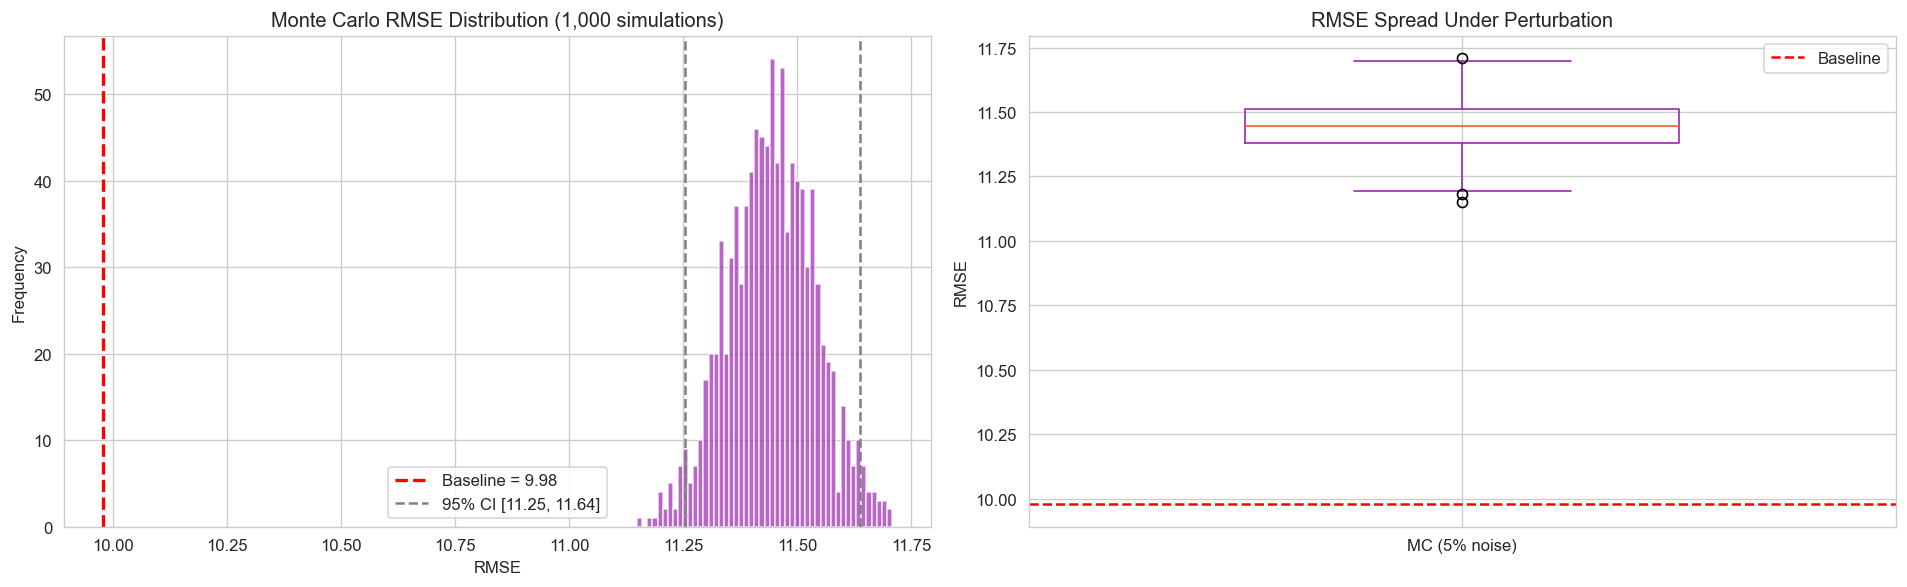

In [3]:
mc_noise_sigma = 0.05 * no2_std
n_mc = 1000
n_mc_days = 30

def run_single_mc(seed):
    rng = np.random.RandomState(seed)
    noisy_history = train_no2 + rng.normal(0, mc_noise_sigma, len(train_no2))
    noisy_actuals = actuals_subset[:n_mc_days] + rng.normal(0, mc_noise_sigma, n_mc_days)
    preds = rolling_predict_n(noisy_history, noisy_actuals, n_mc_days)
    return np.sqrt(np.mean((actuals_subset[:n_mc_days] - np.array(preds))**2))

print(f"Running {n_mc} Monte Carlo simulations across {n_cores} cores (noise sigma={mc_noise_sigma:.2f})...")

start_time = time.time()
mc_rmses = Parallel(n_jobs=n_cores)(delayed(run_single_mc)(i) for i in range(n_mc))
elapsed = time.time() - start_time

mc_rmses = np.array(mc_rmses)
mc_ci_low, mc_ci_high = np.percentile(mc_rmses, [2.5, 97.5])

print(f"\nCompleted in {int(elapsed//60)}m {int(elapsed%60)}s")
print(f"\nMonte Carlo Results (n={n_mc}, noise=5% std):")
print(f"  Mean RMSE:  {mc_rmses.mean():.2f}")
print(f"  Std RMSE:   {mc_rmses.std():.2f}")
print(f"  95% CI:     [{mc_ci_low:.2f}, {mc_ci_high:.2f}]")
print(f"  Baseline:   {baseline_rmse:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(mc_rmses, bins=50, alpha=0.7, color="#9C27B0", edgecolor="white")
axes[0].axvline(baseline_rmse, color="red", linewidth=2, linestyle="--", label=f"Baseline = {baseline_rmse:.2f}")
axes[0].axvline(mc_ci_low, color="grey", linewidth=1.5, linestyle="--")
axes[0].axvline(mc_ci_high, color="grey", linewidth=1.5, linestyle="--",
                label=f"95% CI [{mc_ci_low:.2f}, {mc_ci_high:.2f}]")
axes[0].set_xlabel("RMSE")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Monte Carlo RMSE Distribution (1,000 simulations)")
axes[0].legend()

axes[1].boxplot([mc_rmses], positions=[1], widths=0.5,
                boxprops=dict(color="#9C27B0"), medianprops=dict(color="#FF5722"),
                whiskerprops=dict(color="#9C27B0"), capprops=dict(color="#9C27B0"))
axes[1].axhline(baseline_rmse, color="red", linewidth=1.5, linestyle="--", label="Baseline")
axes[1].set_xticklabels(["MC (5% noise)"])
axes[1].set_ylabel("RMSE")
axes[1].set_title("RMSE Spread Under Perturbation")
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Missing Data Tolerance

Real-world sensors fail. Simulating this by randomly dropping 5% to 30% of training values and replacing them with forward-fill (the same strategy used in the cleaning pipeline). If RMSE barely changes the model is tolerant to gaps in the data.

Running 50 missing data trials across 8 cores...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


  Missing   0.0%: RMSE = 9.77 +/- 0.00
  Missing   5.0%: RMSE = 9.76 +/- 0.02
  Missing  10.0%: RMSE = 9.73 +/- 0.03
  Missing  20.0%: RMSE = 9.68 +/- 0.04
  Missing  30.0%: RMSE = 9.68 +/- 0.08

Completed in 0m 55s


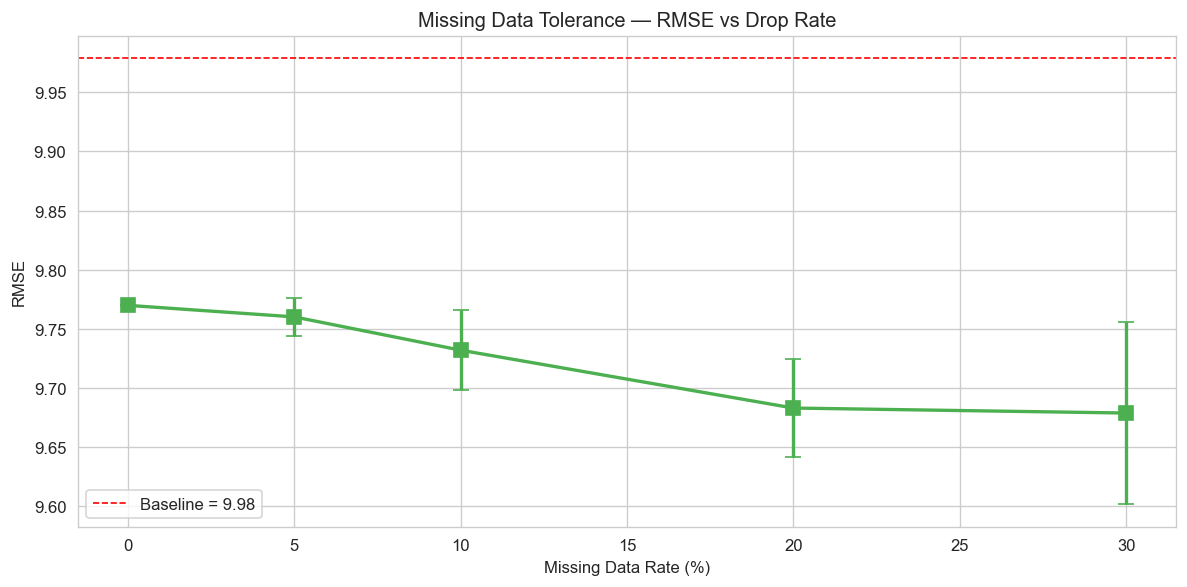


RMSE increase from 0% to 30% missing: -0.9%


In [4]:
missing_rates = [0, 0.05, 0.10, 0.20, 0.30]
n_missing_repeats = 10
n_missing_days = 50

def run_missing_trial(rate, seed):
    rng = np.random.RandomState(seed)
    h = train_no2.copy()
    if rate > 0:
        mask = rng.random(len(h)) < rate
        h[mask] = np.nan
        h = pd.Series(h).ffill().bfill().values
    preds = rolling_predict_n(h, actuals_subset[:n_missing_days], n_missing_days)
    return np.sqrt(np.mean((actuals_subset[:n_missing_days] - np.array(preds))**2))

missing_tasks = [(rate, int(rate * 10000) + rep + 5000)
                 for rate in missing_rates for rep in range(n_missing_repeats)]

print(f"Running {len(missing_tasks)} missing data trials across {n_cores} cores...")

start_time = time.time()
all_missing_rmses = Parallel(n_jobs=n_cores)(delayed(run_missing_trial)(r, s) for r, s in missing_tasks)
elapsed = time.time() - start_time

missing_results = []
idx = 0
for rate in missing_rates:
    rmses = all_missing_rmses[idx:idx + n_missing_repeats]
    idx += n_missing_repeats
    missing_results.append({"missing_pct": rate * 100, "rmse_mean": np.mean(rmses), "rmse_std": np.std(rmses)})
    print(f"  Missing {rate*100:5.1f}%: RMSE = {np.mean(rmses):.2f} +/- {np.std(rmses):.2f}")

missing_df = pd.DataFrame(missing_results)
print(f"\nCompleted in {int(elapsed//60)}m {int(elapsed%60)}s")

fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(missing_df["missing_pct"], missing_df["rmse_mean"], yerr=missing_df["rmse_std"],
            fmt="s-", color="#4CAF50", capsize=5, linewidth=2, markersize=8)
ax.axhline(baseline_rmse, color="red", linestyle="--", linewidth=1, label=f"Baseline = {baseline_rmse:.2f}")
ax.set_xlabel("Missing Data Rate (%)")
ax.set_ylabel("RMSE")
ax.set_title("Missing Data Tolerance — RMSE vs Drop Rate")
ax.legend()
plt.tight_layout()
plt.show()

pct_degradation = ((missing_df["rmse_mean"].iloc[-1] - missing_df["rmse_mean"].iloc[0]) / missing_df["rmse_mean"].iloc[0]) * 100
print(f"\nRMSE increase from 0% to 30% missing: {pct_degradation:.1f}%")

## 4. Outlier Sensitivity

Injecting a single extreme spike (2x, 3x and 5x the max observed NO2) at the end of the training history. Measuring how many days the prediction is affected before recovering to within 1 ug/m3 of the baseline.

Running 4 outlier trials across 8 cores...
Completed in 0m 4s
  2x max outlier: recovers within 1 ug/m3 by day 30
  3x max outlier: recovers within 1 ug/m3 by day 30
  5x max outlier: recovers within 1 ug/m3 by day 30


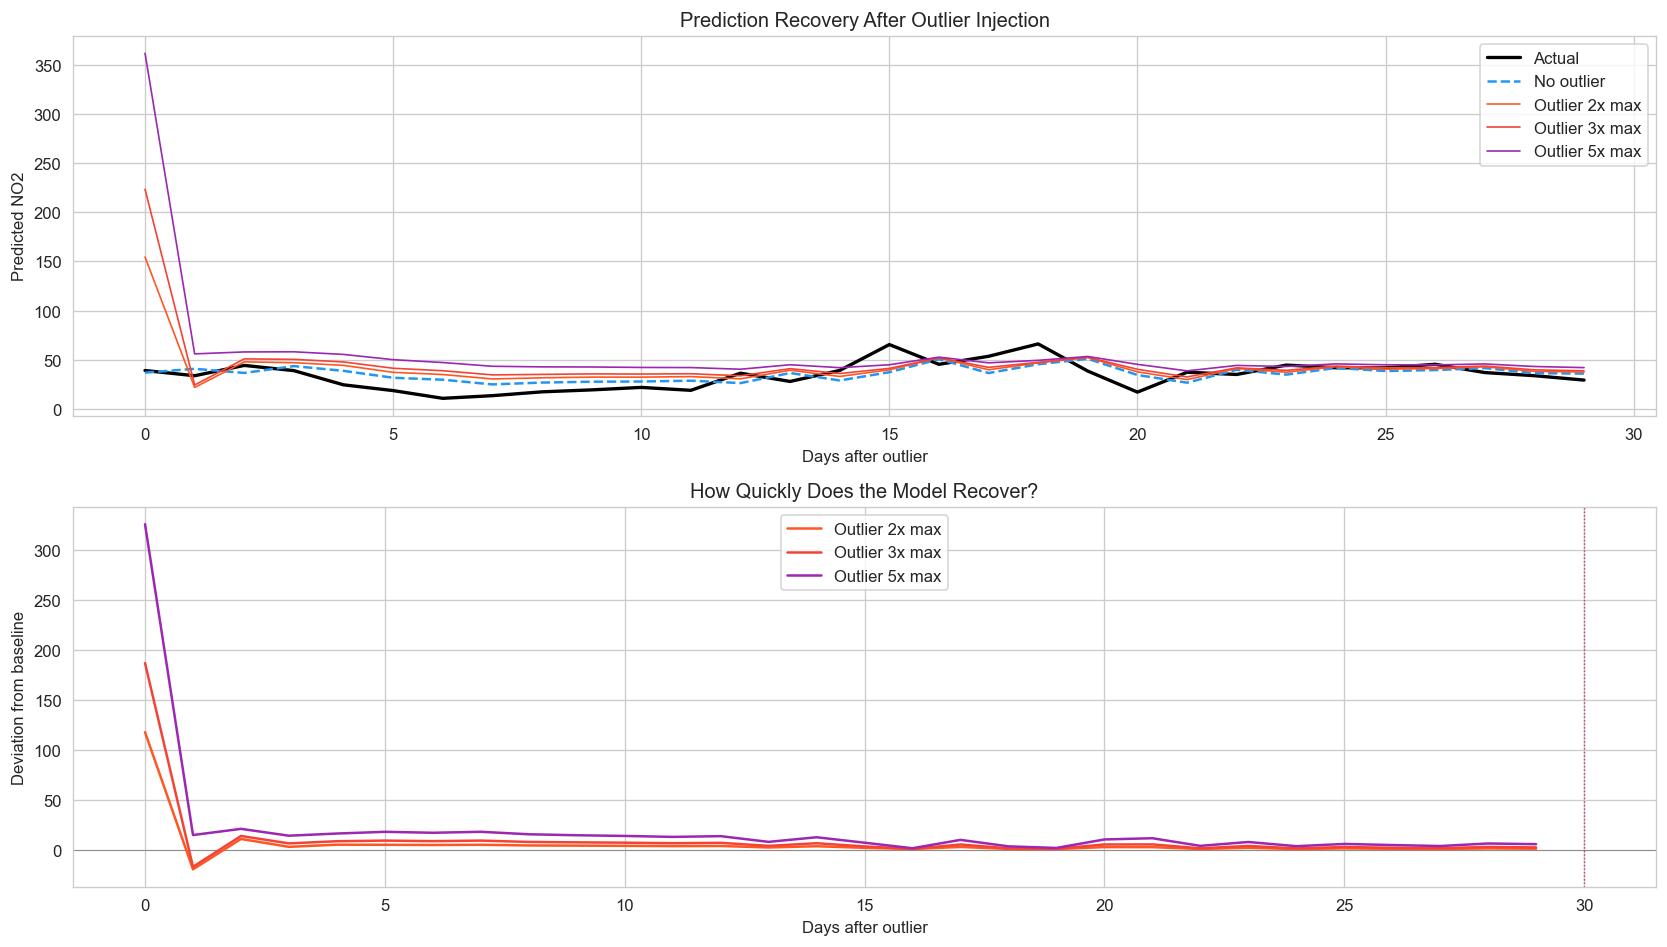

In [5]:
n_outlier_days = 30
outlier_values = [2, 3, 5]

def run_outlier_trial(mult):
    h = train_no2.copy()
    if mult is not None:
        h[-1] = train_no2.max() * mult
    return rolling_predict_n(h, actuals_subset[:n_outlier_days], n_outlier_days)

print(f"Running {len(outlier_values) + 1} outlier trials across {n_cores} cores...")

start_time = time.time()
all_outlier_preds = Parallel(n_jobs=n_cores)(
    delayed(run_outlier_trial)(m) for m in [None] + outlier_values
)
elapsed = time.time() - start_time

baseline_preds = all_outlier_preds[0]
outlier_results = {}
for i, mult in enumerate(outlier_values):
    outlier_results[f"{mult}x max"] = all_outlier_preds[i + 1]

print(f"Completed in {int(elapsed//60)}m {int(elapsed%60)}s")

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(range(n_outlier_days), actuals_subset[:n_outlier_days], "k-", linewidth=2, label="Actual")
axes[0].plot(range(n_outlier_days), baseline_preds, "--", color="#2196F3", linewidth=1.5, label="No outlier")
colours = ["#FF5722", "#f44336", "#9C27B0"]
for (label, preds), colour in zip(outlier_results.items(), colours):
    axes[0].plot(range(n_outlier_days), preds, "-", color=colour, linewidth=1, label=f"Outlier {label}")
axes[0].set_xlabel("Days after outlier")
axes[0].set_ylabel("Predicted NO2")
axes[0].set_title("Prediction Recovery After Outlier Injection")
axes[0].legend()

axes[1].axhline(0, color="grey", linewidth=0.5)
for (label, preds), colour in zip(outlier_results.items(), colours):
    deviation = np.array(preds) - np.array(baseline_preds)
    axes[1].plot(range(n_outlier_days), deviation, "-", color=colour, linewidth=1.5, label=f"Outlier {label}")
    recovery = next((i for i, d in enumerate(deviation) if abs(d) < 1.0), n_outlier_days)
    axes[1].axvline(recovery, color=colour, linewidth=0.8, linestyle=":", alpha=0.5)
    print(f"  {label} outlier: recovers within 1 ug/m3 by day {recovery}")

axes[1].set_xlabel("Days after outlier")
axes[1].set_ylabel("Deviation from baseline")
axes[1].set_title("How Quickly Does the Model Recover?")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Seasonal Robustness

Winter typically has higher NO2 from heating and traffic while summer has lower levels. Splitting the unseen data by season and month to check whether the model performs equally across all periods. Using the Kruskal-Wallis test to determine if seasonal differences are statistically significant.

Seasonal Performance:
  Season       RMSE       MAE        Mean NO2     Days
  ----------------------------------------------------
  Winter       9.59       7.42       34.46        212
  Spring       9.87       8.03       30.87        207
  Summer       11.38      8.81       31.02        177
  Autumn       9.04       7.08       30.69        182


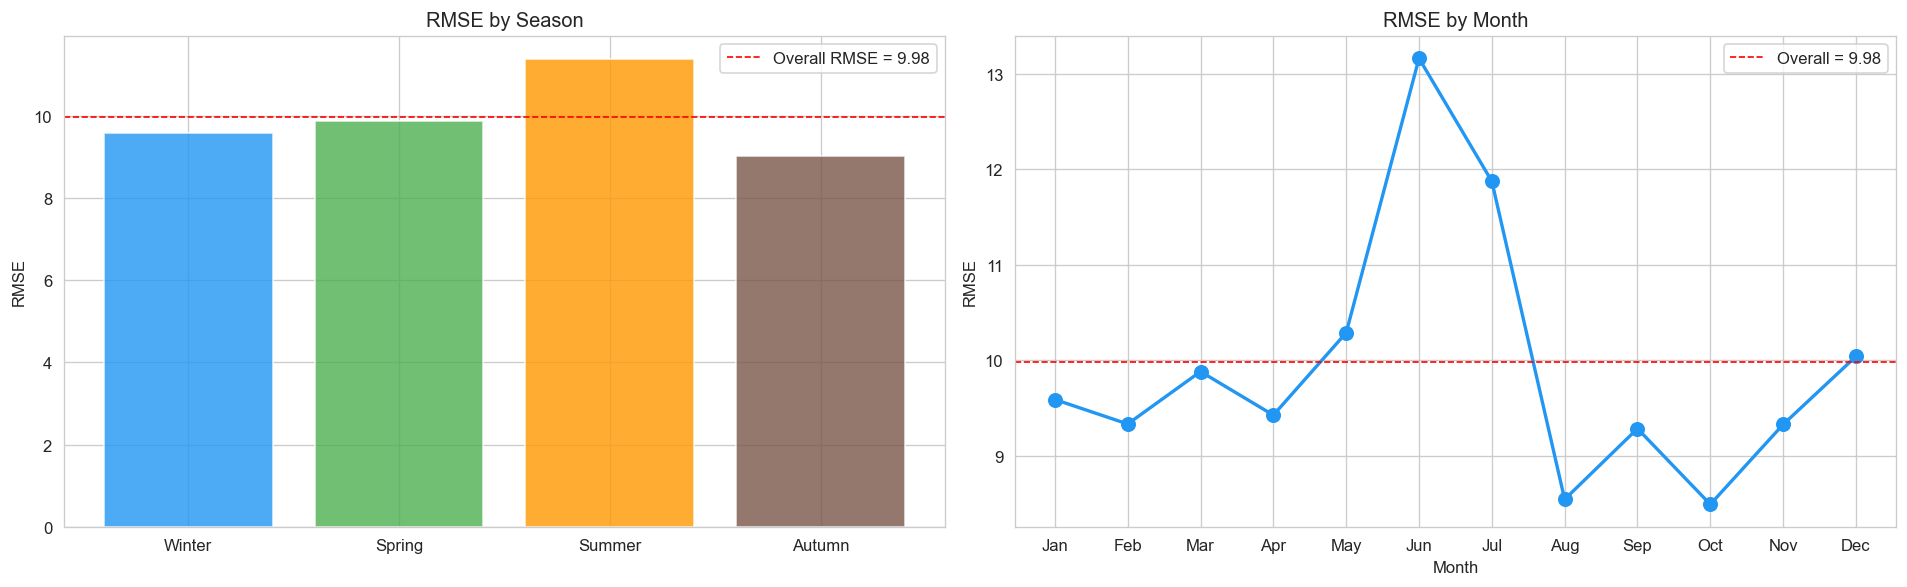


Kruskal-Wallis test (seasonal difference): H=7.95, p=0.0471
Seasons significantly different? YES


In [6]:
# Assign seasons
def get_season(month):
    if month in [12, 1, 2]: return "Winter"
    elif month in [3, 4, 5]: return "Spring"
    elif month in [6, 7, 8]: return "Summer"
    else: return "Autumn"

unseen_seasonal = unseen.copy()
unseen_seasonal["season"] = unseen_seasonal.index.month.map(get_season)
unseen_seasonal["month"] = unseen_seasonal.index.month

# Seasonal RMSE
seasonal_metrics = unseen_seasonal.groupby("season").agg(
    rmse=("error", lambda x: np.sqrt((x**2).mean())),
    mae=("abs_error", "mean"),
    mean_actual=("actual", "mean"),
    count=("actual", "count"),
).reindex(["Winter", "Spring", "Summer", "Autumn"])

print("Seasonal Performance:")
print(f"  {'Season':<12} {'RMSE':<10} {'MAE':<10} {'Mean NO2':<12} {'Days'}")
print(f"  {'-'*52}")
for season, row in seasonal_metrics.iterrows():
    print(f"  {season:<12} {row['rmse']:<10.2f} {row['mae']:<10.2f} {row['mean_actual']:<12.2f} {int(row['count'])}")

# Monthly RMSE
monthly_metrics = unseen_seasonal.groupby("month").agg(
    rmse=("error", lambda x: np.sqrt((x**2).mean())),
    mae=("abs_error", "mean"),
    count=("actual", "count"),
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Seasonal bar chart
season_colours = {"Winter": "#2196F3", "Spring": "#4CAF50", "Summer": "#FF9800", "Autumn": "#795548"}
axes[0].bar(seasonal_metrics.index, seasonal_metrics["rmse"],
            color=[season_colours[s] for s in seasonal_metrics.index], alpha=0.8)
axes[0].axhline(baseline_rmse, color="red", linestyle="--", linewidth=1, label=f"Overall RMSE = {baseline_rmse:.2f}")
axes[0].set_ylabel("RMSE")
axes[0].set_title("RMSE by Season")
axes[0].legend()

# Monthly line chart
axes[1].plot(monthly_metrics.index, monthly_metrics["rmse"], "o-", color="#2196F3", linewidth=2, markersize=8)
axes[1].axhline(baseline_rmse, color="red", linestyle="--", linewidth=1, label=f"Overall = {baseline_rmse:.2f}")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("RMSE")
axes[1].set_title("RMSE by Month")
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
axes[1].legend()

plt.tight_layout()
plt.show()

# Statistical test: is seasonal difference significant?
groups = [unseen_seasonal[unseen_seasonal["season"] == s]["abs_error"].values for s in ["Winter","Spring","Summer","Autumn"]]
kw_stat, kw_p = kruskal(*groups)
print(f"\nKruskal-Wallis test (seasonal difference): H={kw_stat:.2f}, p={kw_p:.4f}")
print(f"Seasons significantly different? {'YES' if kw_p < 0.05 else 'NO'}")

## 6. Summary

In [7]:
print("=" * 65)
print("ROBUSTNESS TESTING SUMMARY")
print("=" * 65)

print(f"\n{'Test':<30} {'Result':<35}")
print(f"{'-'*65}")

# Noise sensitivity
noise_50 = results_df[results_df["noise_pct"] == 50]["rmse_mean"].values[0]
noise_degrade = ((noise_50 - results_df["rmse_mean"].iloc[0]) / results_df["rmse_mean"].iloc[0]) * 100
noise_verdict = "Robust" if noise_degrade < 10 else ("Moderate" if noise_degrade < 25 else "Fragile")
print(f"{'Gaussian Noise (50% std)':<30} {f'RMSE +{noise_degrade:.1f}% — {noise_verdict}':<35}")

# Monte Carlo
mc_spread = mc_rmses.std()
mc_verdict = "Robust" if mc_spread < 1.0 else ("Moderate" if mc_spread < 2.0 else "Unstable")
print(f"{'Monte Carlo (5% noise)':<30} {f'Std={mc_spread:.2f} — {mc_verdict}':<35}")

# Missing data
miss_30 = missing_df[missing_df["missing_pct"] == 30]["rmse_mean"].values[0]
miss_degrade = ((miss_30 - missing_df["rmse_mean"].iloc[0]) / missing_df["rmse_mean"].iloc[0]) * 100
miss_verdict = "Robust" if miss_degrade < 10 else ("Moderate" if miss_degrade < 25 else "Fragile")
print(f"{'Missing Data (30%)':<30} {f'RMSE +{miss_degrade:.1f}% — {miss_verdict}':<35}")

# Seasonal
seasonal_range = seasonal_metrics["rmse"].max() - seasonal_metrics["rmse"].min()
season_verdict = "Consistent" if kw_p > 0.05 else "Seasonal bias"
print(f"{'Seasonal Variation':<30} {f'Range={seasonal_range:.2f}, p={kw_p:.4f} — {season_verdict}':<35}")

# Overall
verdicts = [noise_verdict, mc_verdict, miss_verdict, season_verdict]
robust_count = sum(1 for v in verdicts if v in ["Robust", "Consistent"])

print(f"\n{'='*65}")
print(f"Robust tests: {robust_count}/4")

if robust_count == 4:
    print("VERDICT: Model is robust — production-ready")
elif robust_count >= 3:
    print("VERDICT: Model is largely robust — minor sensitivity identified")
elif robust_count >= 2:
    print("VERDICT: Model has moderate robustness — monitor edge cases")
else:
    print("VERDICT: Model is fragile — consider improvements before production")
print(f"{'='*65}")

ROBUSTNESS TESTING SUMMARY

Test                           Result                             
-----------------------------------------------------------------
Gaussian Noise (50% std)       RMSE +3.9% — Robust                
Monte Carlo (5% noise)         Std=0.10 — Robust                  
Missing Data (30%)             RMSE +-0.9% — Robust               
Seasonal Variation             Range=2.35, p=0.0471 — Seasonal bias

Robust tests: 3/4
VERDICT: Model is largely robust — minor sensitivity identified
